# Ewaluacja modeli klasyfikacyjnych

Od macierzy pomyłek do ROC AUC.

**Plan:**
1. Macierz pomyłek i Accuracy
2. Problem niezbalansowanego datasetu
3. Precision i Recall
4. Próg 0.5 — dlaczego akurat tyle?
5. Krzywa ROC (implementacja od zera)
6. AUC — pole pod krzywą
7. Wersja produkcyjna z scikit-learn

## 1. Dane: 6 zamówień

Model zwrócił prawdopodobieństwo złego doświadczenia (`y_prob`).
Przy **progu 0.5** zamieniamy je na decyzję binarną.

In [14]:
import numpy as np
import pandas as pd

y_true = np.array([1, 1, 1, 0, 0, 0])
y_prob = np.array([0.85, 0.70, 0.40, 0.65, 0.20, 0.15])

y_pred = (y_prob >= 0.5).astype(int)

pd.DataFrame({
    "zamówienie":        range(1, 7),
    "y_true":            y_true,
    "y_prob":            y_prob,
    "y_pred (próg=0.5)": y_pred,
})

,zamówienie,y_true,y_prob,y_pred (próg=0.5)
0,1,1,0.85,1
1,2,1,0.70,1
2,3,1,0.40,0
3,4,0,0.65,1
4,5,0,0.20,0
5,6,0,0.15,0


## 2. Macierz pomyłek

| | Predicted: 0 (OK) | Predicted: 1 (bad) |
|---|---|---|
| **Actual: 0 (OK)** | **TN** True Negative | **FP** False Positive |
| **Actual: 1 (bad)** | **FN** False Negative | **TP** True Positive |

In [16]:
TP = int(((y_true==1) & (y_pred==1)).sum())
FP = int(((y_true==0) & (y_pred==1)).sum())
TN = int(((y_true==0) & (y_pred==0)).sum())
FN = int(((y_true==1) & (y_pred==0)).sum())

print(f"\nTP={TP}, FP={FP}, TN={TN}, FN={FN}")


TP=2, FP=1, TN=2, FN=1


## 3. Accuracy

$$\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}$$

In [17]:
accuracy = (TP + TN) / (TP + TN + FP + FN)

print(f"Accuracy: {accuracy:.2f}")

Accuracy: 0.67


## 4. Problem z Accuracy na niezbalansowanym datasecie

W Olist tylko ~11% zamówień to złe doświadczenia.
Co się stanie, jeśli nasz "model" po prostu zawsze mówi *"wszystko OK"*?

In [18]:
y_true_imb  = np.array([0]*89 + [1]*11)
y_pred_naive = np.zeros(100, dtype=int)   # model zawsze: "OK"

acc_naive = (y_true_imb == y_pred_naive).mean()
detected  = int(((y_pred_naive == 1) & (y_true_imb == 1)).sum())

print(f"Accuracy naiwnego modelu:  {acc_naive:.0%}")
print(f"Wykryte złe zamówienia:    {detected} z {int(y_true_imb.sum())}")
print()
print("→ 89% accuracy, ale model jest bezużyteczny!")

Accuracy naiwnego modelu:  89%
Wykryte złe zamówienia:    0 z 11

→ 89% accuracy, ale model jest bezużyteczny!


## 5. Precision i Recall

**Precision** — z tych, które model oznaczył jako *bad*, ile faktycznie *bad*?

$$\text{Precision} = \frac{TP}{TP + FP}$$

*"Ile moich alarmów było prawdziwych?"*

**Recall** (= Sensitivity = TPR) — z tych, które faktycznie były *bad*, ile model wykrył?

$$\text{Recall} = \frac{TP}{TP + FN}$$

*"Ile złych zamówień mi umknęło?"*

In [19]:
precision = TP / (TP + FP)
recall    = TP / (TP + FN)

print(f"Precision: {precision:.2f}  — z {TP+FP} alarmów, {TP} było trafnych")
print(f"Recall:    {recall:.2f}  — z {TP+FN} złych zamówień wykryliśmy {TP}")

Precision: 0.67  — z 3 alarmów, 2 było trafnych
Recall:    0.67  — z 3 złych zamówień wykryliśmy 2


## 6. Próg 0.5 — dlaczego akurat tyle?

Próg możemy ustawić dowolnie:

- **Wyższy próg** → mniej alarmów, bardziej pewne → wyższa Precision, niższy Recall
- **Niższy próg** → więcej alarmów, łapiemy więcej złych → niższa Precision, wyższy Recall

In [20]:
for threshold in [0.3, 0.5, 0.7]:
    pred = (y_prob >= threshold).astype(int)
    tp_ = int(((y_true==1) & (pred==1)).sum())
    fp_ = int(((y_true==0) & (pred==1)).sum())
    fn_ = int(((y_true==1) & (pred==0)).sum())
    p = tp_ / (tp_ + fp_) if (tp_ + fp_) > 0 else 0.0
    r = tp_ / (tp_ + fn_) if (tp_ + fn_) > 0 else 0.0
    print(f"próg={threshold}  pred={list(pred)}  Precision={p:.2f}  Recall={r:.2f}")

próg=0.3  pred=[1, 1, 1, 1, 0, 0]  Precision=0.75  Recall=1.00
próg=0.5  pred=[1, 1, 0, 1, 0, 0]  Precision=0.67  Recall=0.67
próg=0.7  pred=[1, 1, 0, 0, 0, 0]  Precision=1.00  Recall=0.67


## 7. Krzywa ROC — implementacja od zera

ROC (Receiver Operating Characteristic) pokazuje kompromis między:

- **TPR** (True Positive Rate) = Recall = $\frac{TP}{TP+FN}$ — oś Y
- **FPR** (False Positive Rate) = $\frac{FP}{FP+TN}$ — oś X

Dla każdego możliwego progu wyliczamy parę (FPR, TPR) i rysujemy krzywą.

In [21]:
thresholds = np.arange(0.0, 1.05, 0.1)
tpr_list, fpr_list = [], []

for t in thresholds:
    pred = (y_prob >= t).astype(int)
    tp_ = int(((y_true==1) & (pred==1)).sum())
    fp_ = int(((y_true==0) & (pred==1)).sum())
    tn_ = int(((y_true==0) & (pred==0)).sum())
    fn_ = int(((y_true==1) & (pred==0)).sum())
    tpr_list.append(tp_ / (tp_ + fn_) if (tp_ + fn_) > 0 else 0.0)
    fpr_list.append(fp_ / (fp_ + tn_) if (fp_ + tn_) > 0 else 0.0)

print(f"{'próg':>5} | {'TPR':>5} | {'FPR':>5}")
print("-" * 22)
for t, tpr, fpr in zip(thresholds, tpr_list, fpr_list):
    print(f"{t:>5.1f} | {tpr:>5.2f} | {fpr:>5.2f}")

 próg |   TPR |   FPR
----------------------
  0.0 |  1.00 |  1.00
  0.1 |  1.00 |  1.00
  0.2 |  1.00 |  0.67
  0.3 |  1.00 |  0.33
  0.4 |  1.00 |  0.33
  0.5 |  0.67 |  0.33
  0.6 |  0.67 |  0.33
  0.7 |  0.33 |  0.00
  0.8 |  0.33 |  0.00
  0.9 |  0.00 |  0.00
  1.0 |  0.00 |  0.00


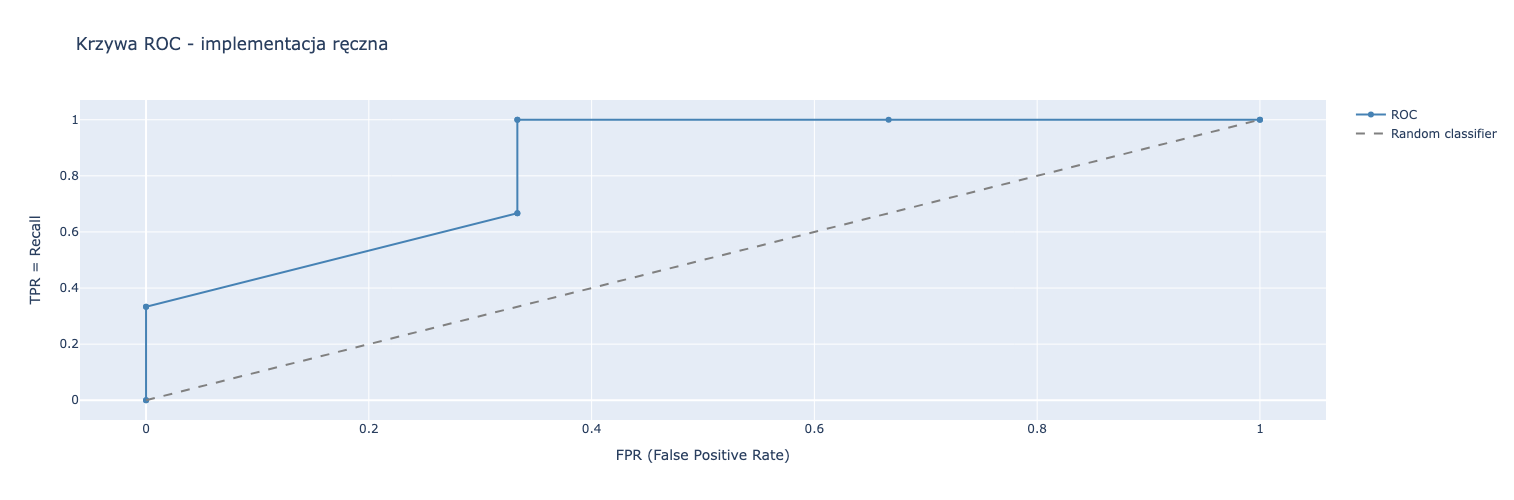

In [23]:
import plotly.graph_objects as go

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=fpr_list, y=tpr_list, mode="lines+markers",
    name="ROC", line=dict(color="steelblue", width=2),
    text=[f"próg={t:.1f}" for t in thresholds],
    hovertemplate="FPR=%{x:.2f}, TPR=%{y:.2f}<br>%{text}",
))
fig.add_trace(go.Scatter(
    x=[0, 1], y=[0, 1], mode="lines",
    line=dict(dash="dash", color="gray"), name="Random classifier",
))
fig.update_layout(
    title="Krzywa ROC - implementacja ręczna",
    xaxis_title="FPR (False Positive Rate)",
    yaxis_title="TPR = Recall",
    width=600, height=500,
)
fig.show()

## 8. AUC - pole pod krzywą

- **AUC = 1.0** → idealny model
- **AUC = 0.5** → losowe zgadywanie
- **AUC < 0.5** → model gorszy niż losowy

In [25]:
fpr_arr = np.array(fpr_list)
tpr_arr = np.array(tpr_list)
order   = np.argsort(fpr_arr)
auc_manual = np.trapz(tpr_arr[order], fpr_arr[order])

print(f"AUC (metoda trapezów): {auc_manual:.3f}")

AUC (metoda trapezów): 0.778


## 9. Wersja produkcyjna — scikit-learn

Teraz rozumiesz co się dzieje pod spodem.

In [26]:
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_curve, roc_auc_score,
)

print(confusion_matrix(y_true, y_pred))
print()
print(classification_report(y_true, y_pred, target_names=["OK", "bad"]))

[[2 1]
 [1 2]]

              precision    recall  f1-score   support

          OK       0.67      0.67      0.67         3
         bad       0.67      0.67      0.67         3

    accuracy                           0.67         6
   macro avg       0.67      0.67      0.67         6
weighted avg       0.67      0.67      0.67         6



In [ ]:
fpr_sk, tpr_sk, _ = roc_curve(y_true, y_prob)
auc_sk = roc_auc_score(y_true, y_prob)

print(f"AUC (sklearn): {auc_sk:.3f}")

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=fpr_sk, y=tpr_sk, mode="lines",
    name=f"ROC AUC={auc_sk:.3f}", line=dict(color="steelblue", width=2),
))
fig.add_trace(go.Scatter(
    x=[0, 1], y=[0, 1], mode="lines",
    line=dict(dash="dash", color="gray"), name="Random",
))
fig.update_layout(
    title="Krzywa ROC (sklearn)",
    xaxis_title="FPR", yaxis_title="TPR",
    width=600, height=500,
)
fig.show()